# Ensemble Learning — Notebook

**Course:** Machine Learning  
**Tools:** Python (scikit-learn, numpy, pandas, matplotlib)

Notebook ini berisi contoh implementasi dan eksperimen singkat untuk teknik ensemble: Bagging / Random Forest, Boosting (AdaBoost, Gradient Boosting), Voting, dan Stacking.

## 0 — Setup

Pastikan paket yang diperlukan terinstal. Cell berikut mencoba menginstal paket bila belum ada.

In [1]:
# Jika perlu, uncomment dan jalankan baris instalasi ini.
# !pip install scikit-learn matplotlib pandas numpy xgboost

import importlib
required = ["sklearn", "matplotlib", "pandas", "numpy"]
missing = [p for p in required if importlib.util.find_spec(p) is None]
print("Missing packages (if empty, all present):", missing)

Missing packages (if empty, all present): []


## 1 — Imports dan util function

Load library umum dan fungsi util untuk evaluasi.

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.datasets import load_iris, make_classification
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

## 2 — Data: Iris (multiclass) & Synthetic binary classification

Kita akan gunakan dataset Iris untuk contoh multiclass dan dataset sintetik untuk contoh binary (lebih realistis untuk boosting/voting experiments).

In [3]:
# Iris dataset (multiclass)

iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Synthetic binary dataset (balanced)
X_syn, y_syn = make_classification(n_samples=2000, n_features=20, n_informative=6, n_redundant=2,
                                   n_clusters_per_class=2, weights=[0.5,0.5], random_state=42)

# Train/test split
Xir_train, Xir_test, yir_train, yir_test = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris)
Xsyn_train, Xsyn_test, ysyn_train, ysyn_test = train_test_split(X_syn, y_syn, test_size=0.25, random_state=42, stratify=y_syn)

print('Iris shape:', X_iris.shape, ' Synthetic shape:', X_syn.shape)

Iris shape: (150, 4)  Synthetic shape: (2000, 20)


## 3 — Random Forest (Bagging)

Random Forest sebagai contoh bagging: paralel training banyak decision tree dengan subset fitur acak.

== Results: RandomForest (synthetic) ==
Accuracy: 0.916
Classification report:
               precision    recall  f1-score   support

           0       0.89      0.95      0.92       250
           1       0.94      0.88      0.91       250

    accuracy                           0.92       500
   macro avg       0.92      0.92      0.92       500
weighted avg       0.92      0.92      0.92       500

Confusion matrix:
 [[237  13]
 [ 29 221]]


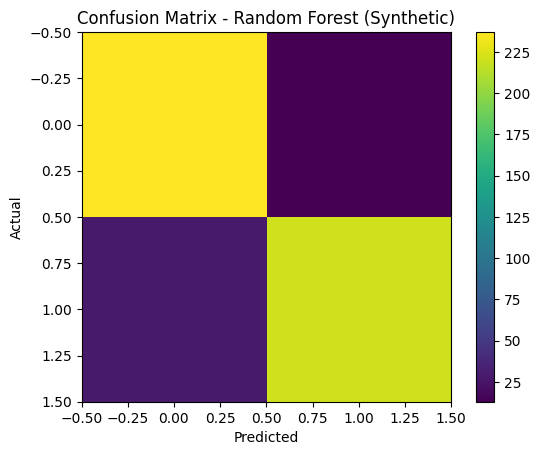

In [4]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Small helper to show metrics
def evaluate_model(model, X_train, X_test, y_train, y_test, name=None):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"== Results: {name or model.__class__.__name__} ==")
    print("Accuracy:", round(acc, 4))
    print("Classification report:\n", classification_report(y_test, preds))
    cm = confusion_matrix(y_test, preds)
    print("Confusion matrix:\n", cm)
    return acc, cm, preds

acc_rf, cm_rf, preds_rf = evaluate_model(rf, Xsyn_train, Xsyn_test, ysyn_train, ysyn_test, name='RandomForest (synthetic)')

# Plot confusion matrix (single plot — matplotlib)
plt.figure()
plt.imshow(cm_rf, interpolation='nearest')
plt.title('Confusion Matrix - Random Forest (Synthetic)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.colorbar()
plt.show()

## 4 — AdaBoost (Boosting)

Contoh AdaBoost dengan base estimator default (DecisionTree stump).

== Results: AdaBoost (synthetic) ==
Accuracy: 0.888
Classification report:
               precision    recall  f1-score   support

           0       0.85      0.94      0.89       250
           1       0.93      0.84      0.88       250

    accuracy                           0.89       500
   macro avg       0.89      0.89      0.89       500
weighted avg       0.89      0.89      0.89       500

Confusion matrix:
 [[234  16]
 [ 40 210]]


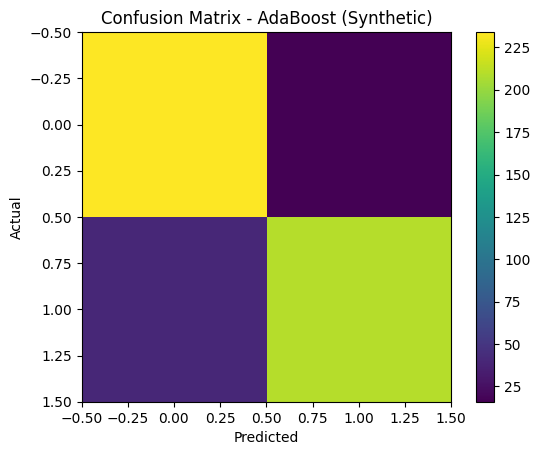

In [5]:
ada = AdaBoostClassifier(n_estimators=100, learning_rate=0.8, random_state=42)
acc_ada, cm_ada, preds_ada = evaluate_model(ada, Xsyn_train, Xsyn_test, ysyn_train, ysyn_test, name='AdaBoost (synthetic)')

plt.figure()
plt.imshow(cm_ada, interpolation='nearest')
plt.title('Confusion Matrix - AdaBoost (Synthetic)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.colorbar()
plt.show()

## 5 — Gradient Boosting

Menggunakan `GradientBoostingClassifier` dari scikit-learn.

== Results: GradientBoosting (synthetic) ==
Accuracy: 0.912
Classification report:
               precision    recall  f1-score   support

           0       0.91      0.92      0.91       250
           1       0.92      0.91      0.91       250

    accuracy                           0.91       500
   macro avg       0.91      0.91      0.91       500
weighted avg       0.91      0.91      0.91       500

Confusion matrix:
 [[229  21]
 [ 23 227]]


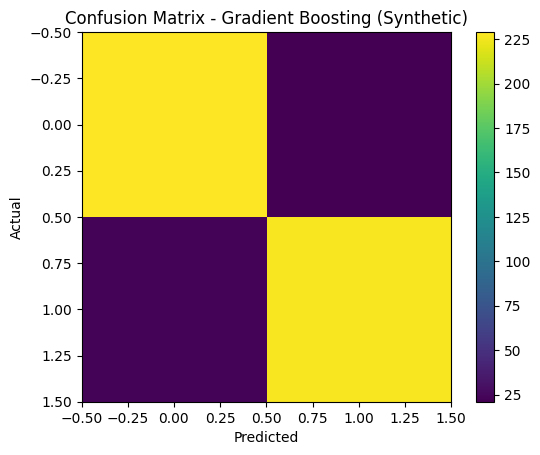

In [6]:
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
acc_gb, cm_gb, preds_gb = evaluate_model(gb, Xsyn_train, Xsyn_test, ysyn_train, ysyn_test, name='GradientBoosting (synthetic)')

plt.figure()
plt.imshow(cm_gb, interpolation='nearest')
plt.title('Confusion Matrix - Gradient Boosting (Synthetic)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.colorbar()
plt.show()

## 6 — Voting Classifier

Soft voting dari beberapa classifier (LogisticRegression, DecisionTree, SVC). Perhatikan SVC membutuhkan `probability=True` jika ingin soft voting.

== Results: Voting (soft) ==
Accuracy: 0.904
Classification report:
               precision    recall  f1-score   support

           0       0.88      0.93      0.91       250
           1       0.93      0.88      0.90       250

    accuracy                           0.90       500
   macro avg       0.91      0.90      0.90       500
weighted avg       0.91      0.90      0.90       500

Confusion matrix:
 [[233  17]
 [ 31 219]]


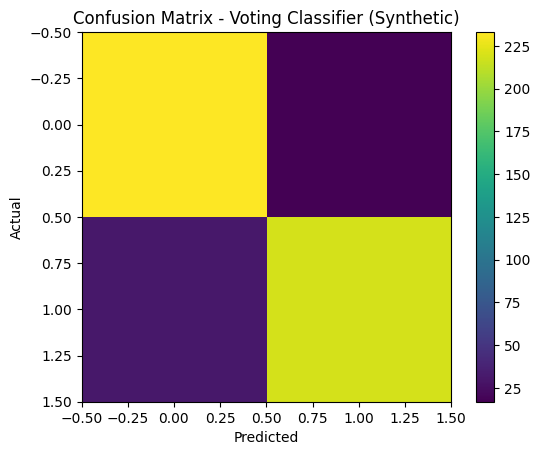

In [7]:
lr = LogisticRegression(max_iter=200)
dt = DecisionTreeClassifier()
svc = SVC(probability=True)

voting = VotingClassifier(estimators=[('lr', lr), ('dt', dt), ('svc', svc)], voting='soft')
acc_voting, cm_voting, preds_voting = evaluate_model(voting, Xsyn_train, Xsyn_test, ysyn_train, ysyn_test, name='Voting (soft)')

plt.figure()
plt.imshow(cm_voting, interpolation='nearest')
plt.title('Confusion Matrix - Voting Classifier (Synthetic)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.colorbar()
plt.show()

## 7 — Stacking Classifier

Stacking: gabungkan prediksi model dasar dan latih meta-estimator (di sini LogisticRegression).

== Results: Stacking (synthetic) ==
Accuracy: 0.928
Classification report:
               precision    recall  f1-score   support

           0       0.91      0.94      0.93       250
           1       0.94      0.91      0.93       250

    accuracy                           0.93       500
   macro avg       0.93      0.93      0.93       500
weighted avg       0.93      0.93      0.93       500

Confusion matrix:
 [[236  14]
 [ 22 228]]


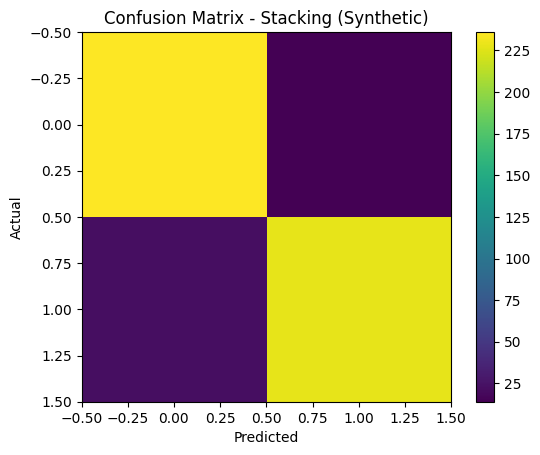

In [8]:
estimators = [
    ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=50, random_state=42)),
    ('dt', DecisionTreeClassifier())
]
stack = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(), cv=5)
acc_stack, cm_stack, preds_stack = evaluate_model(stack, Xsyn_train, Xsyn_test, ysyn_train, ysyn_test, name='Stacking (synthetic)')

plt.figure()
plt.imshow(cm_stack, interpolation='nearest')
plt.title('Confusion Matrix - Stacking (Synthetic)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.colorbar()
plt.show()

## 8 — Cross-validation comparison (quick)

Perbandingan sederhana dengan cross-validation pada synthetic dataset (5-fold).

In [9]:
models = {
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Voting': VotingClassifier(estimators=[('lr', LogisticRegression(max_iter=200)), ('dt', DecisionTreeClassifier()), ('svc', SVC(probability=True))], voting='soft'),
    'Stacking': StackingClassifier(estimators=[('rf', RandomForestClassifier(n_estimators=50, random_state=42)), ('gb', GradientBoostingClassifier(n_estimators=50, random_state=42))], final_estimator=LogisticRegression(), cv=5)
}

cv_results = {}
for name, model in models.items():
    print('Running CV for', name)
    scores = cross_val_score(model, X_syn, y_syn, cv=5, scoring='accuracy', n_jobs=1)
    cv_results[name] = scores
    print('Scores:', scores, ' Mean:', scores.mean())


Running CV for RandomForest
Scores: [0.9175 0.9425 0.9025 0.93   0.91  ]  Mean: 0.9205
Running CV for AdaBoost
Scores: [0.89   0.8775 0.875  0.9    0.8825]  Mean: 0.885
Running CV for GradientBoosting
Scores: [0.9025 0.9175 0.9    0.9325 0.9175]  Mean: 0.914
Running CV for Voting
Scores: [0.8825 0.92   0.895  0.92   0.895 ]  Mean: 0.9024999999999999
Running CV for Stacking
Scores: [0.905  0.9425 0.905  0.93   0.92  ]  Mean: 0.9205000000000002


## 9 — Kelebihan & Kekurangan (Ringkasan)

**Kelebihan:**
- Meningkatkan akurasi
- Robust terhadap noise
- Bisa mengurangi bias/variance tergantung metode

**Kekurangan:**
- Training lebih lama / resource intensive
- Interpretasi model lebih sulit
- Memerlukan tuning hyperparameter

## 10 — Further reading & practical tips

- Coba GridSearchCV / RandomizedSearchCV untuk tuning hyperparameter
- Untuk data besar, gunakan LightGBM / XGBoost (lebih cepat) — perlu instalasi tambahan
- Perhatikan imbalance class; gunakan stratify pada split atau teknik balancing (SMOTE, class_weight, dll.)

---

**Selesai.** Notebook ini cocok dijalankan di Jupyter / Colab. Kamu bisa menambahkan visualisasi lebih kaya atau cell interaktif jika perlu.